# Free spectrum tutorial

In [1]:
%load_ext autoreload
%autoreload 2
import logging
from pathlib import Path

logging.basicConfig(level="INFO")

import arviz as az
import jax
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt

from angst import analysis, dataset, simulation, utils
import pandas as pd

INFO:arviz.preview:arviz_base not installed
INFO:arviz.preview:arviz_stats not installed
INFO:arviz.preview:arviz_plots not installed
INFO:2025-10-23 21:04:35,964:jax._src.xla_bridge:808: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


## Creating a simulated dataset
To be completely self-contained, we'll make our own DRW dataset.

In [2]:
# Set parameters for simulation
rng_key = jax.random.key(0)
tspan, cadence, season = 365 * 10, 7, None
timestamps = utils.make_timestamps(tspan, cadence, rng_key)
mask = utils.make_season_mask(timestamps, season)
timestamps_season = timestamps[mask]
amplitude = dist.Uniform(1e-3, 3)
timescale = dist.Normal(180, 60)
cadence = cadence
snr = 20
mean_mag = 16
seed_num = 0
out_file = Path.cwd() / "drw-simulation.pq"

agn_id = 3

# Create simulation object
drw = simulation.DampedRandomWalkSim(
    amplitude, timescale, cadence, snr, mean_mag, seed_num, season, tspan
)

# Run the simulation
drw.simulate(out_file, rng_key, 5)

# Read in the simulation and check some data
dset = dataset.DataSet(out_file, name="Example Simulation")
dset.get_cols_for_id(agn_id, "lc.mjd", "lc.mag", "lc.mag_error", bands="r")

INFO:angst.simulation:Simulated data saved at /home/dave/Dropbox/Documents/research/hazgrav/codes/angst_dev/docs/drw-simulation.pq.
/home/dave/Dropbox/Documents/research/hazgrav/codes/angst_dev/.venv/lib/python3.13/site-packages/nested_pandas/nestedframe/core.py:339: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


lc
3  [{mjd: 0.995522, mag: 16.425891, mag_error: 1....

## It's just a (Nested) Pandas DataFrame
We can do typical operations, like plotting

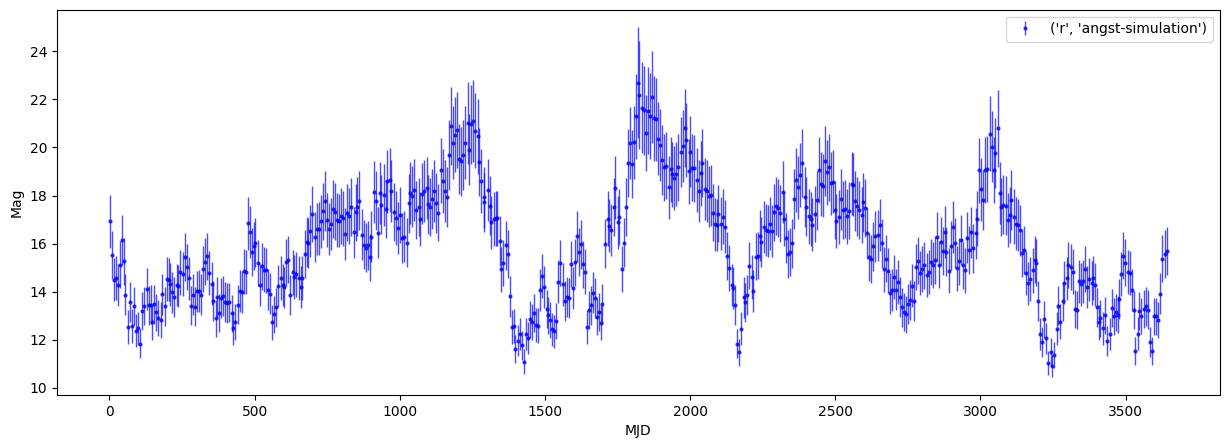

In [3]:
colors = ["blue", "green", "red", "orange"]
fig, ax = plt.subplots(figsize=(15, 5))
for i, (name, group) in enumerate(dset.df.iloc[0]["lc"].groupby(["band", "survey"])):
    ax.errorbar(
        x=group.mjd,
        y=group.mag,
        yerr=group.mag_error,
        marker="o",
        linestyle="",
        ms=2,
        elinewidth=1,
        label=name,
        alpha=0.7,
        color=colors[i],
    )
ax.set_xlabel("MJD")
ax.set_ylabel("Mag")
_ = ax.legend()

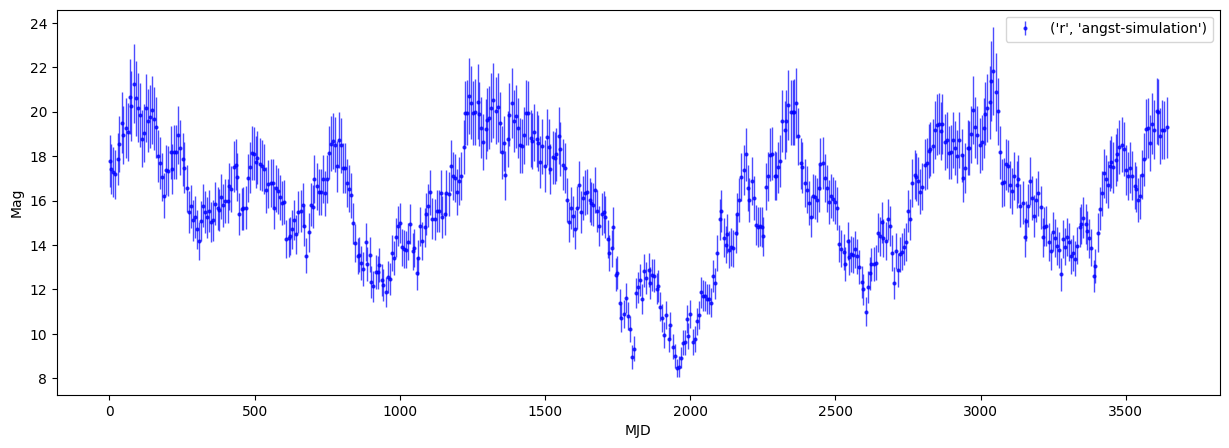

In [4]:
fig, ax = plt.subplots(figsize=(15, 5))
for i, (name, group) in enumerate(dset.df.iloc[4]["lc"].groupby(["band", "survey"])):
    ax.errorbar(
        x=group.mjd,
        y=group.mag,
        yerr=group.mag_error,
        marker="o",
        linestyle="",
        ms=2,
        elinewidth=1,
        label=name,
        alpha=0.7,
        color=colors[i],
    )
ax.set_xlabel("MJD")
ax.set_ylabel("Mag")
_ = ax.legend()

The input parameters are saved in the dataframe as a nested dataframe `input_parameters`

In [5]:
dset.df.head()

id          ra        dec  \
0   0  234.692012  45.102399   
1   1  145.523735  -66.04436   
2   2  278.718174  29.627104   
3   3   15.412092 -46.341703   
4   4  203.802929  60.215188   

                                                  lc  \
0  [{mjd: 1.400884, mag: 16.925767, mag_error: 1....   
1  [{mjd: 0.44321, mag: 16.866241, mag_error: 1.4...   
2  [{mjd: 0.380826, mag: 17.417877, mag_error: 1....   
3  [{mjd: 0.995522, mag: 16.425891, mag_error: 1....   
4  [{mjd: 1.763224, mag: 17.77974, mag_error: 1.1...   

                                    input_parameters  
0  [{DRW_amplitude: 2.693091, DRW_timescale: 170....  
1  [{DRW_amplitude: 0.673117, DRW_timescale: 191....  
2  [{DRW_amplitude: 1.191862, DRW_timescale: 172....  
3  [{DRW_amplitude: 2.026526, DRW_timescale: 246....  
4  [{DRW_amplitude: 2.477241, DRW_timescale: 170....

In [6]:
dset.df.input_parameters.explode().head()

,DRW_amplitude,DRW_timescale,cadence,season_start,season_finish,snr,timespan,mean_mag,jax_key_data_0,jax_key_data_1
0,2.693091,170.123269,7,0,365.25,20,3650,16,928981903,3453687069
1,0.673117,191.360792,7,0,365.25,20,3650,16,1353695780,2116000888
2,1.191862,172.304976,7,0,365.25,20,3650,16,3531307783,465290248
3,2.026526,246.514252,7,0,365.25,20,3650,16,1539457558,118255239
4,2.477241,170.814763,7,0,365.25,20,3650,16,4274742258,3380111416


In [7]:
# Make an analysis object
freespec = analysis.SingleAGNFreeSpectrum(dataset=dset, agn_id=0, bands="r", nfreq=5)

/home/dave/Dropbox/Documents/research/hazgrav/codes/angst_dev/.venv/lib/python3.13/site-packages/nested_pandas/nestedframe/core.py:339: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


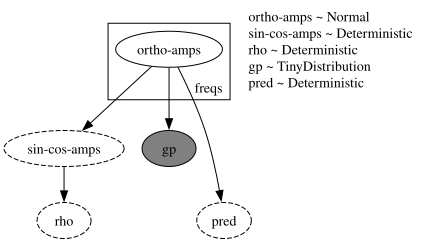

In [8]:
# Visualize the model
gviz_digraph = freespec.render_model(render_distributions=True)
gviz_digraph.unflatten(stagger=2)

## Set up NUTS with NumPyro
The angst analysis objects implement NumPyro models. We can pass the object to NumPyro for easy inference.

In [9]:
# Configure NUTS
rng_key = jax.random.key(0)

nuts_kernel = NUTS(model=freespec)

num_chains = 3
num_samples = 3_000
num_warmup = 1_000

In [10]:
# Run the sampler, supplying the observational data to infer from
mcmc = MCMC(
    nuts_kernel,
    num_warmup=num_warmup,
    num_samples=num_samples,
    num_chains=num_chains,
    progress_bar=True,
    chain_method="vectorized",
    jit_model_args=True,
)

mcmc.run(rng_key, freespec.agn_mjd, freespec.agn_lc_err, freespec.agn_lc_zero_mean)

sample: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:52<00:00, 75.83it/s]


In [11]:
# ArviZ works well with NumPyro output
data = az.from_numpyro(mcmc)
az.summary(
    data,
    var_names=[v for v in data.posterior.data_vars if v != "pred"],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ortho-amps[0],-10.631,0.957,-12.410,-8.820,0.007,0.011,18437.0,6595.0,1.0
ortho-amps[1],-9.670,0.993,-11.541,-7.871,0.008,0.011,17389.0,6872.0,1.0
ortho-amps[2],-1.128,0.989,-2.930,0.771,0.008,0.011,15880.0,6834.0,1.0
ortho-amps[3],-23.264,0.996,-25.150,-21.416,0.007,0.012,17653.0,6885.0,1.0
ortho-amps[4],-1.914,1.032,-3.966,-0.098,0.008,0.012,18819.0,6046.0,1.0
ortho-amps[5],-0.386,1.125,-2.481,1.687,0.008,0.013,17920.0,6711.0,1.0
ortho-amps[6],7.690,0.982,5.805,9.481,0.007,0.012,18179.0,5969.0,1.0
ortho-amps[7],16.514,1.043,14.586,18.462,0.008,0.012,18167.0,6314.0,1.0
ortho-amps[8],6.811,1.009,4.878,8.679,0.008,0.012,17906.0,6842.0,1.0
ortho-amps[9],-19.016,0.926,-20.762,-17.320,0.007,0.010,17008.0,7526.0,1.0


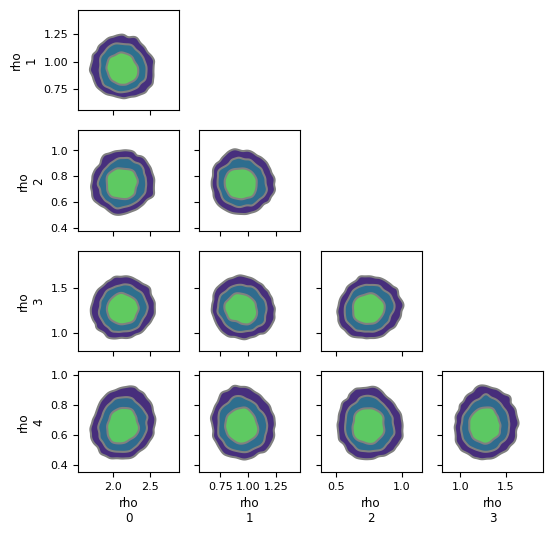

In [12]:
_ = az.plot_pair(data, var_names=["rho"], kind="kde", figsize=(6, 6), textsize=8)

### Store Fourier coefficients
Some downstream analyses can make use of this data

In [13]:
coeff_chains = az.extract(data, var_names="sin-cos-amps").values  # shape (dim, samples)
coeff_df = pd.DataFrame(
    dict(zip([f"sin_cos_amps_{i}" for i in range(coeff_chains.shape[0])], coeff_chains.tolist()))
)
coeff_df["id"] = agn_id
coeff_df.head()

,sin_cos_amps_0,sin_cos_amps_1,sin_cos_amps_2,sin_cos_amps_3,sin_cos_amps_4,sin_cos_amps_5,sin_cos_amps_6,sin_cos_amps_7,sin_cos_amps_8,sin_cos_amps_9,id
0,-1.480382,-0.887860,-0.114502,0.825083,-0.770745,0.095355,0.280943,-0.776706,0.836858,0.069267,3
1,-1.444396,-0.915301,-0.159351,0.697480,-0.891627,0.042693,0.355498,-0.732369,0.889768,-0.051573,3
2,-1.452270,-0.986390,-0.152288,0.686836,-0.840894,0.091486,0.292538,-0.741152,0.779113,-0.116320,3
3,-1.462947,-0.962272,-0.131686,0.681512,-0.878246,0.091405,0.314405,-0.771389,0.833069,-0.049885,3
4,-1.485167,-0.881588,-0.108656,0.738357,-0.752285,0.065362,0.252788,-0.940336,0.951742,0.069152,3


In [14]:
# using the agn_id we chose earlier
single_agn_df = dset.df.query(f"id == {agn_id}")
single_agn_df = single_agn_df.join_nested(coeff_df, "sin_cos_amps", on="id")
single_agn_df

id         ra        dec  \
3   3  15.412092 -46.341703   

                                                  lc  \
3  [{mjd: 0.995522, mag: 16.425891, mag_error: 1....   

                                    input_parameters  \
3  [{DRW_amplitude: 2.026526, DRW_timescale: 246....   

                                        sin_cos_amps  
3  [{sin_cos_amps_0: -1.480382, sin_cos_amps_1: -...

We can save this to disk

In [15]:
single_agn_df.to_parquet("free-spec-analyses-w-coefficients.pq")

In [16]:
del (
    data,
    mcmc,
)  # For memory constraints when running the entire notebook at once on GPU, VRAM is scarce!

## Supply your own sampler
If you don't want to use NumPyro, you can extract the log-likelihood and other useful information to pass to your favorite sampler. In the example below, we use BlackJAX.

In [17]:
# Get initial sample
initial_position = freespec.initial_sample(rng_key)
initial_position

{'ortho-amps': Array([ 1.59065191, -0.11220091,  0.91298267, -1.70563723, -0.70458132,
         1.50451393, -0.71422555, -1.33954298,  1.16239045,  0.07790811],      dtype=float64)}

In [18]:
# Get log-likelihood, JIT it, and test on initial sample
ll = jax.jit(freespec.loglikelihood)
ll(initial_position)

Array(-2079.11517304, dtype=float64)

In [21]:
# Set up BlackJAX kernel and run the adaptation
import blackjax

rng_key = jax.random.key(0)

adapt = blackjax.window_adaptation(blackjax.nuts, ll, target_acceptance_rate=0.8)
rng_key, warmup_key = jax.random.split(rng_key)
(last_state, parameters), _ = adapt.run(warmup_key, initial_position, num_warmup)
kernel = blackjax.nuts(ll, **parameters).step

In [22]:
# Inference loops for single chains or vectorized chains
def inference_loop(rng_key, kernel, initial_state, num_samples):
    @jax.jit
    def one_step(state, rng_key):
        state, info = kernel(rng_key, state)
        return state, (state, info)

    keys = jax.random.split(rng_key, num_samples)
    _, (states, infos) = jax.lax.scan(one_step, initial_state, keys)

    return states, (
        infos.acceptance_rate,
        infos.is_divergent,
        infos.num_integration_steps,
    )


def inference_loop_multiple_chains(rng_key, kernel, initial_state, num_samples, num_chains):
    @jax.jit
    def one_step(states, rng_key):
        keys = jax.random.split(rng_key, num_chains)
        states, _ = jax.vmap(kernel)(keys, states)
        return states, states

    keys = jax.random.split(rng_key, num_samples)
    _, states = jax.lax.scan(one_step, initial_state, keys)

    return states

In [23]:
# Run one chain
rng_key, sample_key = jax.random.split(rng_key)
states, infos = inference_loop(sample_key, kernel, last_state, num_samples)

BlackJAX doesn't know about the deterministic sites in our model, but we can use the `post_process` method to extract them.

In [24]:
deterministic_points = jax.vmap(
    freespec.post_process(freespec.agn_mjd, freespec.agn_lc_err, freespec.agn_lc_zero_mean)
)({"ortho-amps": states.position["ortho-amps"]})

# Massage the data into a form ArviZ can ingest
idata = az.from_dict(
    posterior={k: v[None, ...] for k, v in states.position.items()}
    | {k: v[None, ...] for k, v in deterministic_points.items()}
)

In [25]:
az.summary(
    idata,
    var_names=[v for v in idata.posterior.data_vars if v != "pred"],
)

Shape validation failed: input_shape: (1, 3000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ortho-amps[0],-10.629,0.981,-12.469,-8.834,0.012,0.019,6208.0,2124.0,NaN
ortho-amps[1],-9.653,0.991,-11.431,-7.752,0.014,0.019,5131.0,2335.0,NaN
ortho-amps[2],-1.139,1.037,-2.943,0.910,0.013,0.019,6303.0,2381.0,NaN
ortho-amps[3],-23.291,1.015,-25.317,-21.474,0.013,0.019,5690.0,2238.0,NaN
ortho-amps[4],-1.913,1.009,-3.764,-0.007,0.013,0.021,5962.0,2005.0,NaN
ortho-amps[5],-0.376,1.113,-2.560,1.737,0.015,0.025,5461.0,2247.0,NaN
ortho-amps[6],7.704,0.920,5.979,9.498,0.012,0.019,5744.0,2274.0,NaN
ortho-amps[7],16.517,1.033,14.670,18.505,0.014,0.022,5113.0,2148.0,NaN
ortho-amps[8],6.811,0.987,5.006,8.662,0.013,0.019,6080.0,2124.0,NaN
ortho-amps[9],-18.991,0.900,-20.716,-17.373,0.014,0.017,4219.0,2412.0,NaN


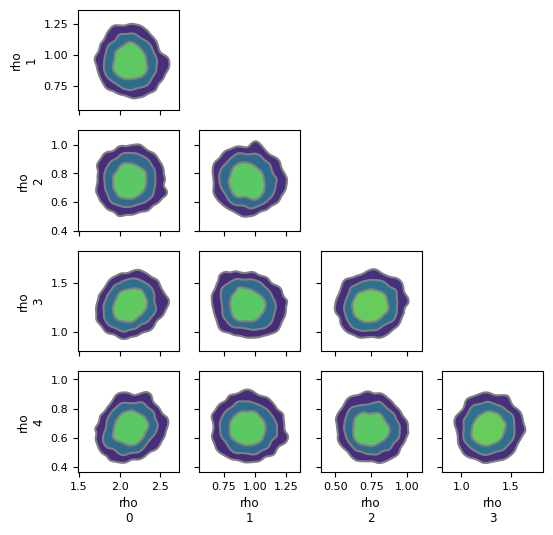

In [26]:
_ = az.plot_pair(idata, var_names=["rho"], kind="kde", figsize=(6, 6), textsize=8)
del idata, states, deterministic_points

## Sample multiple chains with BlackJAX
This is slightly more complicated than with NumPyro.

In [27]:
# We need multiple keys and initial samples = number of chains
rng_keys = jax.random.split(rng_key, num_chains)
initial_samples = jax.vmap(freespec.initial_sample)(rng_keys)

In [28]:
initial_samples

{'ortho-amps': Array([[ 1.59065191, -0.11220091,  0.91298267, -1.70563723, -0.70458132,
          1.50451393, -0.71422555, -1.33954298,  1.16239045,  0.07790811],
        [ 1.59065191, -0.11220091,  0.91298267, -1.70563723, -0.70458132,
          1.50451393, -0.71422555, -1.33954298,  1.16239045,  0.07790811],
        [ 1.59065191, -0.11220091,  0.91298267, -1.70563723, -0.70458132,
          1.50451393, -0.71422555, -1.33954298,  1.16239045,  0.07790811]],      dtype=float64)}

In [29]:
vmap_kernel = blackjax.nuts(ll, **parameters)
initial_states = jax.vmap(vmap_kernel.init, in_axes=(0))(initial_samples)

In [30]:
rng_key, sample_key = jax.random.split(rng_key)
states = inference_loop_multiple_chains(
    sample_key, vmap_kernel.step, initial_states, num_samples, num_chains
)
_ = states.position["ortho-amps"].block_until_ready()

In [31]:
# We transform the results again and reshape for ArviZ
deterministic_points = jax.lax.map(
    freespec.post_process(freespec.agn_mjd, freespec.agn_lc_err, freespec.agn_lc_zero_mean),
    {"ortho-amps": states.position["ortho-amps"].reshape((num_samples * num_chains, -1))},
    batch_size=500,
)
deterministic_points = {
    k: v.reshape((num_chains, num_samples, -1)) for k, v in deterministic_points.items()
}
idata = az.from_dict(
    posterior={k: v for k, v in states.position.items()}
    | {k: v for k, v in deterministic_points.items()}
)

In [32]:
idata

Inference data with groups:
	> posterior

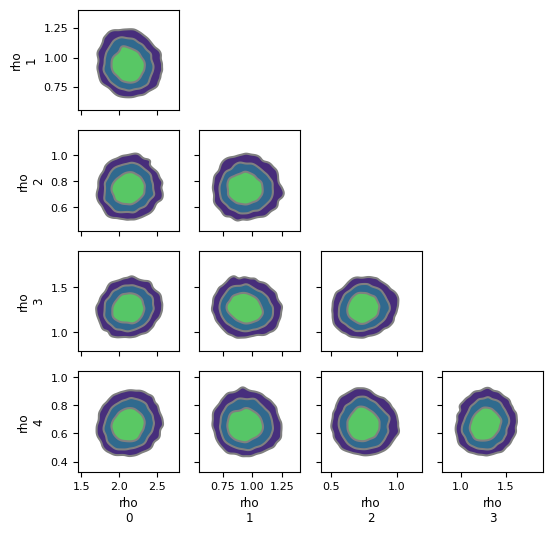

In [34]:
# Removing a short burn in phase
_ = az.plot_pair(
    idata.sel(draw=slice(100, None), groups="posterior"),
    var_names=["rho"],
    kind="kde",
    figsize=(6, 6),
    textsize=8,
)